# 📊 Matplotlib Fundamentals
**Analytics Club — Learners' Space 2026 | Phase 1**

Matplotlib is Python's most widely-used plotting library. It's verbose compared to Seaborn,
but the extra control is worth it. I now understand why people say:
*'Use Seaborn for quick stats plots, use Matplotlib when you need full control.'*

---

## 1. Two Ways to Use Matplotlib

There's a **MATLAB-style** interface (`plt.plot(...)`) and an **object-oriented** interface
(`fig, ax = plt.subplots()`). The OO style is recommended for anything beyond a quick look —
it's clearer when working with multiple subplots and custom layouts.

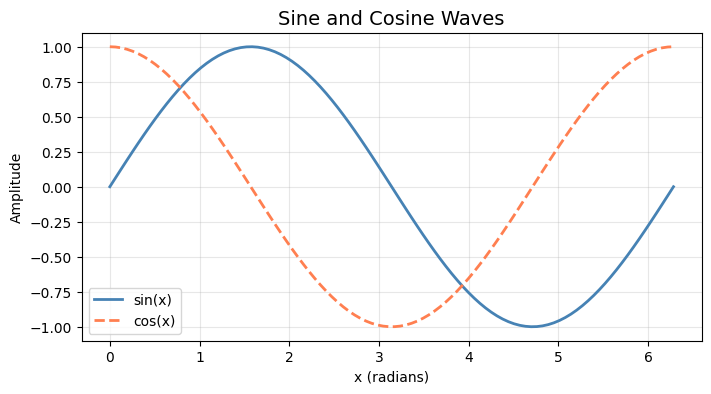

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
print('Matplotlib version:', plt.matplotlib.__version__)

# MATLAB-style (quick and dirty)
# plt.plot([1,2,3], [4,5,6])
# plt.title('Quick plot')
# plt.show()

# OO style (recommended)
fig, ax = plt.subplots(figsize=(8, 4))

x = np.linspace(0, 2*np.pi, 100)
ax.plot(x, np.sin(x), label='sin(x)', color='steelblue', linewidth=2)
ax.plot(x, np.cos(x), label='cos(x)', color='coral', linewidth=2, linestyle='--')

ax.set_title('Sine and Cosine Waves', fontsize=14)
ax.set_xlabel('x (radians)')
ax.set_ylabel('Amplitude')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 2. Scatter Plots

Scatter plots are great for exploring relationships between two continuous variables.
Adding a trend line immediately makes it more insightful.

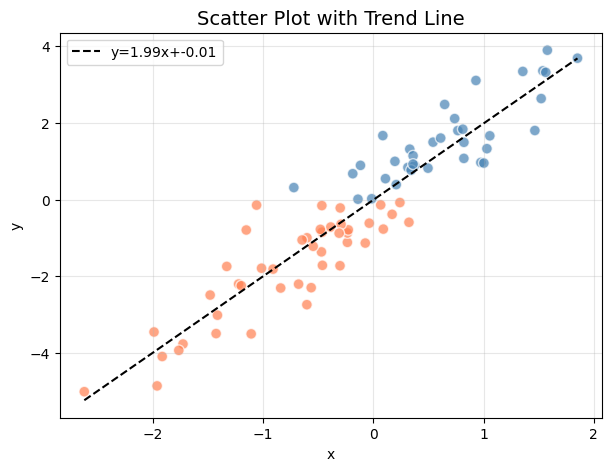

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

np.random.seed(42)
n = 80
x = np.random.randn(n)
y = 2*x + np.random.randn(n)*0.8

fig, ax = plt.subplots(figsize=(7, 5))

colors = np.where(y > 0, 'steelblue', 'coral')
ax.scatter(x, y, c=colors, alpha=0.7, edgecolors='white', s=60)

# Add trend line
m, b = np.polyfit(x, y, 1)
xline = np.linspace(x.min(), x.max(), 100)
ax.plot(xline, m*xline + b, 'k--', linewidth=1.5, label=f'y = {m:.2f}x + {b:.2f}')

ax.set_title('Scatter Plot with Trend Line', fontsize=14)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Bar Charts

Bar charts for comparing categories. Always label the bars — it makes reading
the values much easier without needing to trace grid lines.

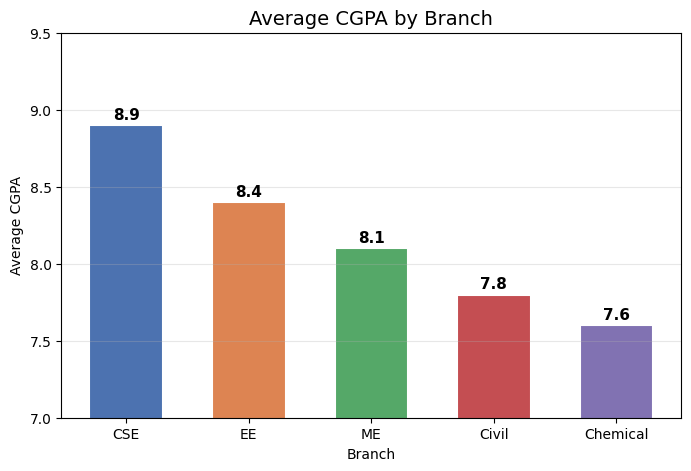

In [ ]:
import matplotlib.pyplot as plt

branches = ['CSE', 'EE', 'ME', 'Civil', 'Chemical']
avg_cgpa = [8.9, 8.4, 8.1, 7.8, 7.6]
colors   = ['#4C72B0','#DD8452','#55A868','#C44E52','#8172B2']

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(branches, avg_cgpa, color=colors, edgecolor='white',
              linewidth=1.5, width=0.6)

# Label each bar with its value
for bar, val in zip(bars, avg_cgpa):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            str(val), ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_title('Average CGPA by Branch', fontsize=14)
ax.set_xlabel('Branch')
ax.set_ylabel('Average CGPA')
ax.set_ylim(7.0, 9.5)
ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Subplots — Multiple Plots in One Figure

`plt.subplots(nrows, ncols)` returns a figure and a 2D array of `Axes` objects.
This is extremely useful for showing multiple related plots together.

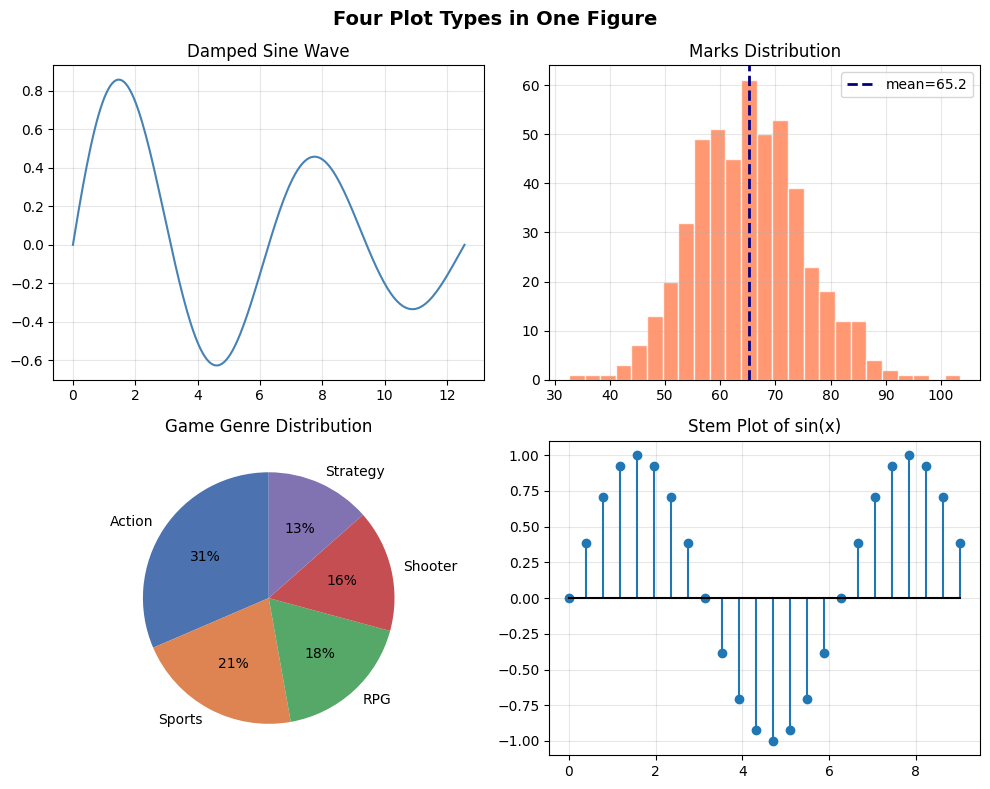

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
fig.suptitle('Four Plot Types in One Figure', fontsize=14, fontweight='bold')

# Top-left: Damped sine wave
t = np.linspace(0, 4*np.pi, 200)
axes[0,0].plot(t, np.sin(t)*np.exp(-t/10), color='steelblue')
axes[0,0].set_title('Damped Sine Wave')
axes[0,0].grid(True, alpha=0.3)

# Top-right: Histogram
np.random.seed(42)
data = np.random.normal(65, 10, 500)
axes[0,1].hist(data, bins=25, color='coral', edgecolor='white', alpha=0.8)
axes[0,1].axvline(data.mean(), color='navy', linestyle='--',
                  linewidth=2, label=f'mean={data.mean():.1f}')
axes[0,1].set_title('Marks Distribution')
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

# Bottom-left: Pie chart
genres = ['Action', 'Sports', 'RPG', 'Shooter', 'Strategy']
sizes  = [28, 19, 16, 14, 12]
axes[1,0].pie(sizes, labels=genres, autopct='%1.0f%%', startangle=90,
              colors=['#4C72B0','#DD8452','#55A868','#C44E52','#8172B2'])
axes[1,0].set_title('Game Genre Distribution')

# Bottom-right: Stem plot
x2 = np.arange(0, 3*np.pi, np.pi/8)
axes[1,1].stem(x2, np.sin(x2), linefmt='C0-', markerfmt='C0o', basefmt='k-')
axes[1,1].set_title('Stem Plot of sin(x)')
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Styling and Customization

Matplotlib has built-in style sheets that change the overall look instantly.
You can also customise every single element manually — fonts, colors, tick sizes, etc.

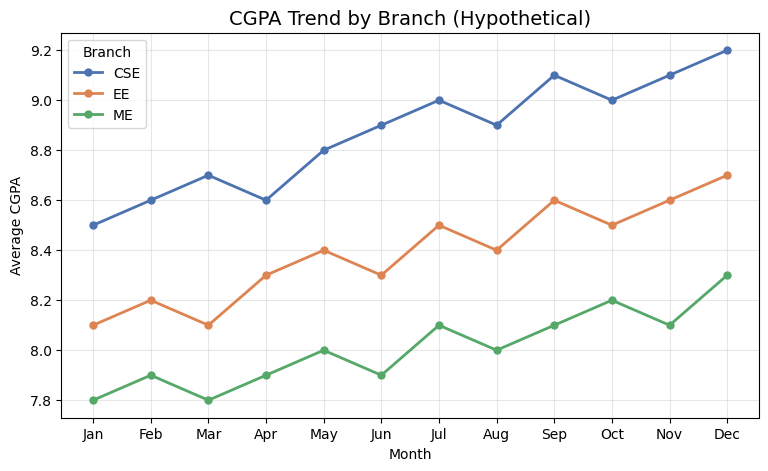

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
branch_data = {
    'CSE': [8.5,8.6,8.7,8.6,8.8,8.9,9.0,8.9,9.1,9.0,9.1,9.2],
    'EE' : [8.1,8.2,8.1,8.3,8.4,8.3,8.5,8.4,8.6,8.5,8.6,8.7],
    'ME' : [7.8,7.9,7.8,7.9,8.0,7.9,8.1,8.0,8.1,8.2,8.1,8.3],
}
colors_map = {'CSE':'#4C72B0','EE':'#DD8452','ME':'#55A868'}

fig, ax = plt.subplots(figsize=(9, 5))

for branch, vals in branch_data.items():
    ax.plot(range(12), vals, marker='o', label=branch,
            color=colors_map[branch], linewidth=2, markersize=5)

ax.set_xticks(range(12))
ax.set_xticklabels(months, rotation=30)
ax.set_title('CGPA Trend by Branch (Hypothetical)', fontsize=14)
ax.set_xlabel('Month')
ax.set_ylabel('Average CGPA')
ax.legend(title='Branch')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Saving Figures

Always save with `bbox_inches='tight'` to avoid clipping labels.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(6, 4))
x = np.linspace(-3, 3, 100)
ax.plot(x, x**2, color='steelblue', linewidth=2)
ax.set_title('y = x²')
ax.grid(True, alpha=0.3)

# Save as PNG (high DPI for reports)
fig.savefig('parabola.png', dpi=150, bbox_inches='tight')

# Save as SVG (vector — scales infinitely)
fig.savefig('parabola.svg', bbox_inches='tight')

print('Figure saved successfully!')
plt.show()

Figure saved successfully!

## 7. Key Matplotlib Concepts — Summary

| Concept | What it does |
|---------|-------------|
| `fig, ax = plt.subplots()` | Create a figure and axes |
| `ax.plot()` | Line plot |
| `ax.scatter()` | Scatter plot |
| `ax.bar()` | Bar chart |
| `ax.hist()` | Histogram |
| `ax.pie()` | Pie chart |
| `ax.set_title()` | Set title |
| `ax.set_xlabel/ylabel()` | Axis labels |
| `ax.legend()` | Show legend |
| `ax.grid()` | Show grid |
| `ax.set_xlim/ylim()` | Set axis range |
| `fig.savefig()` | Save to file |
| `plt.tight_layout()` | Fix overlapping elements |